In [20]:
!pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# CRISP-DM: Modelo de Clasificación para Riesgo de Crédito
Implementar la metodología CRISP-DM para construir un
modelo de clasificación que prediga el nivel de riesgo de impago
de un cliente, basándose en sus características personales,
financieras y crediticias.

**Variable objetivo:** Score — Nivel de riesgo del cliente


In [21]:

url= 'https://raw.githubusercontent.com/Camilahoyosp93/CRISP-DM-Modelo-de-Clasificacion-de-clientes-riesgosos-ante-un-credito-/refs/heads/main/datos_caso_4.csv'
df= pd.read_csv(url, sep=';')
df.head()

,Status of existing checking account,Duration in months,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Score
0,Negative,6,critical account/ other credits existing (not ...,radio/television,1169,unknown / no savings account,more than 7 years,4,male (single),none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",Yes,good
1,0 - 200,48,existing credits paid back duly till now,radio/television,5951,less than 100,1 to 4 years,2,female (divorced/separated/married),none,...,real estate,22,none,own,1,skilled employee / official,1,none,Yes,bad
2,No checking account,12,critical account/ other credits existing (not ...,education,2096,less than 100,4 to 7 years,2,male (single),none,...,real estate,49,none,own,1,unskilled - resident,2,none,Yes,good
3,Negative,42,existing credits paid back duly till now,furniture/equipment,7882,less than 100,4 to 7 years,2,male (single),guarantor,...,building society savings agreement/ life insur...,45,none,for free,1,skilled employee / official,2,none,Yes,good
4,Negative,24,delay in paying off in the past,car (new),4870,less than 100,1 to 4 years,3,male (single),none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,Yes,bad


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Status of existing checking account                       1000 non-null   object
 1   Duration in months                                        1000 non-null   int64 
 2   Credit history                                            1000 non-null   object
 3   Purpose                                                   1000 non-null   object
 4   Credit amount                                             1000 non-null   int64 
 5   Savings account/bonds                                     1000 non-null   object
 6   Present employment since                                  1000 non-null   object
 7   Installment rate in percentage of disposable income       1000 non-null   int64 
 8   Personal status and sex      

In [23]:
df.describe()

,Duration in months,Credit amount,Installment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [24]:
#Nos señala que no hay valores nulos, pero igual lo confirmaremos
nulos = pd.DataFrame({"nulos": df.isnull().sum()})
print(nulos)

                                                    nulos
Status of existing checking account                     0
Duration in months                                      0
Credit history                                          0
Purpose                                                 0
Credit amount                                           0
Savings account/bonds                                   0
Present employment since                                0
Installment rate in percentage of disposable in...      0
Personal status and sex                                 0
Other debtors / guarantors                              0
Present residence since                                 0
Property                                                0
Age in years                                            0
Other installment plans                                 0
Housing                                                 0
Number of existing credits at this bank                 0
Job           

DISTRIBUCIÓN VARIABLE OBJETIVO
Score
good    700
bad     300
Name: count, dtype: int64
Buen pagador (good): {conteo['good']} clientes → {conteo['good']/len(df)*100:.1f}%
Mal pagador  (bad):  {conteo['bad']} clientes → {conteo['bad']/len(df)*100:.1f}%


/tmp/ipykernel_4607/2364234347.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Score", data=df, palette=["#FF5722", "#2196F3"])


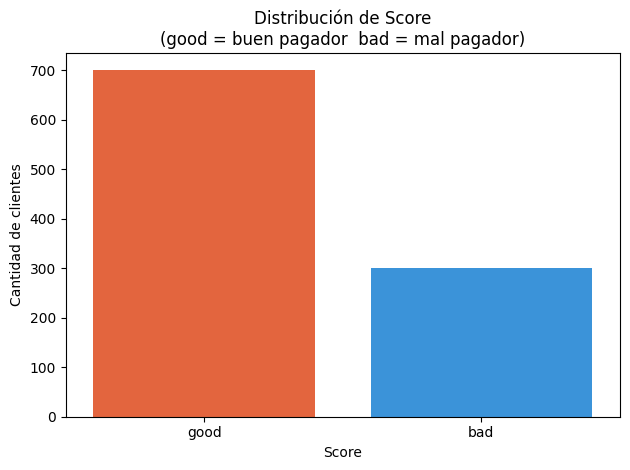

In [25]:

print("DISTRIBUCIÓN VARIABLE OBJETIVO")
conteo = df["Score"].value_counts()
print(conteo)
print("Buen pagador (good): {conteo['good']} clientes → {conteo['good']/len(df)*100:.1f}%")
print("Mal pagador  (bad):  {conteo['bad']} clientes → {conteo['bad']/len(df)*100:.1f}%")

sns.countplot(x="Score", data=df, palette=["#FF5722", "#2196F3"])
plt.title("Distribución de Score\n(good = buen pagador  bad = mal pagador)")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

Vemos que el dataset esta desbalanceado, si entranos con estos datos vamos a tener de resultado un modelo obsoleto asi que tendremos que balancearlo


In [26]:
df['Score'] = df['Score'].str.strip().replace({'good': 1, 'bad': 0})
print("Después:", df['Score'].unique())
print("NaN:", df['Score'].isnull().sum())


Después: [1 0]
NaN: 0


/tmp/ipykernel_4607/973881783.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Score'] = df['Score'].str.strip().replace({'good': 1, 'bad': 0})


In [27]:
#Codificamos las demas variables
le = LabelEncoder()
cols_categoricas = df.select_dtypes(include='object').columns
for col in cols_categoricas:
    df[col] = le.fit_transform(df[col])


In [28]:
df.head()

,Status of existing checking account,Duration in months,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Score
0,1,6,1,7,1169,4,4,4,3,2,...,2,67,1,1,2,1,1,1,1,1
1,0,48,3,7,5951,2,0,2,0,2,...,2,22,1,1,1,1,1,0,1,0
2,2,12,1,4,2096,2,1,2,3,2,...,2,49,1,1,1,3,2,0,1,1
3,1,42,3,5,7882,2,1,2,3,1,...,0,45,1,0,1,1,2,0,1,1
4,1,24,2,1,4870,2,0,3,3,2,...,3,53,1,0,2,1,2,0,1,0


In [29]:
X = df.drop(columns=['Score'])
y = df['Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {len(X_train)} clientes")
print(f"Prueba: {len(X_test)} clientes")

Entrenamiento: 800 clientes
Prueba: 200 clientes


In [30]:
print(f"NaN en y: {y.isnull().sum()}")
print(f"NaN en X: {X.isnull().sum().sum()}")
print(f"Valores únicos en y: {y.unique()}")

NaN en y: 0
NaN en X: 0
Valores únicos en y: [1 0]


In [31]:
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X_train, y_train)

print(f"Antes   good: {sum(y_train==1)}  bad: {sum(y_train==0)}")
print(f"Después good: {sum(y_bal==1)}  bad: {sum(y_bal==0)}")

Antes   good: 559  bad: 241
Después good: 559  bad: 559


In [32]:
#Entrenaremos 3 modelos y basandonos en las metricas elegerimos el mejor

# Modelo Árbol de decisión
tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_bal, y_bal)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [33]:
# Modelo Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_bal, y_bal)

RandomForestClassifier(random_state=42)

In [34]:
#Modelo de regresion logistica
lr = LogisticRegression(random_state=42, max_iter=5000)
lr.fit(X_bal, y_bal)

LogisticRegression(max_iter=5000, random_state=42)

In [35]:
modelos = {
    'Árbol de Decisión': tree,
    'Regresión Logística': lr,
    'Random Forest': rf
}

resultados = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    reporte = classification_report(y_test, y_pred,
                                    target_names=['bad', 'good'],
                                    output_dict=True)
    resultados.append({
        'Modelo': nombre,
        'Accuracy': f"{accuracy_score(y_test, y_pred):.2%}",
        'Precision (bad)': f"{reporte['bad']['precision']:.2%}",
        'Recall (bad)': f"{reporte['bad']['recall']:.2%}",
        'Precision (good)': f"{reporte['good']['precision']:.2%}",
        'Recall (good)': f"{reporte['good']['recall']:.2%}"
    })

pd.DataFrame(resultados).set_index('Modelo')

,Accuracy,Precision (bad),Recall (bad),Precision (good),Recall (good)
Modelo,,,,,
Árbol de Decisión,71.00%,50.79%,54.24%,80.29%,78.01%
Regresión Logística,66.50%,43.55%,45.76%,76.81%,75.18%
Random Forest,72.50%,53.45%,52.54%,80.28%,80.85%


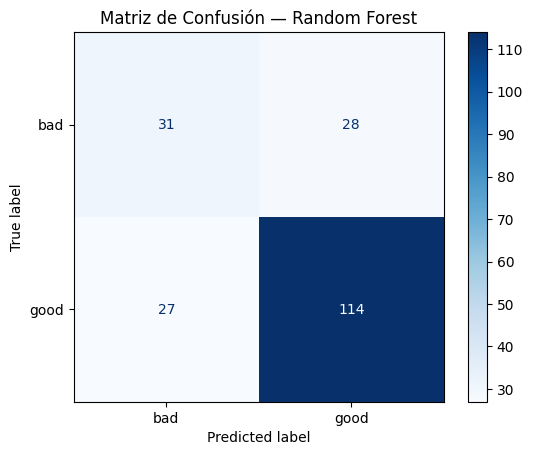

In [36]:

y_pred = rf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['bad', 'good'],
    cmap='Blues')
plt.title('Matriz de Confusión — Random Forest')
plt.show()

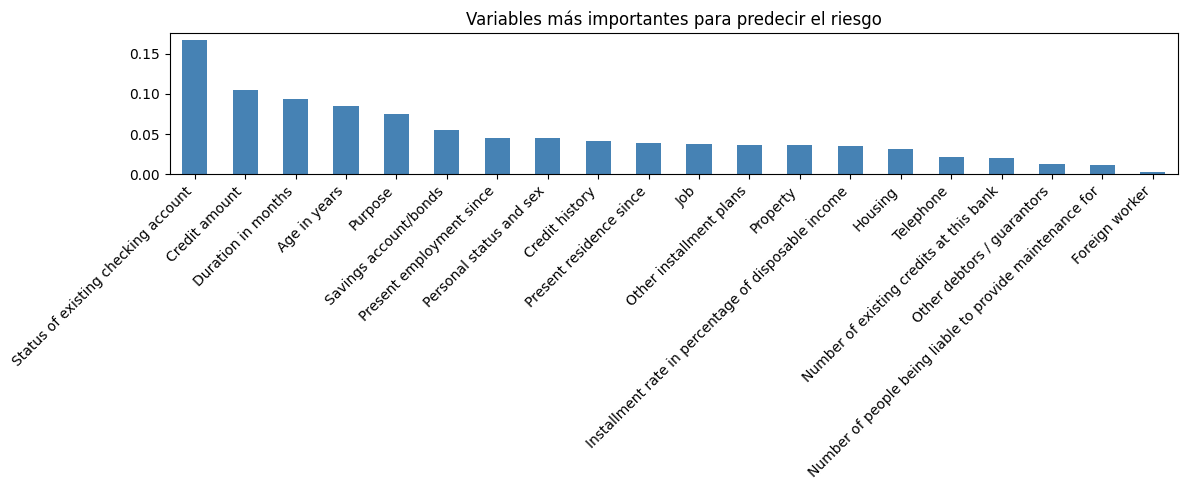

In [37]:
importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns).sort_values(ascending=False)

importancias.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Variables más importantes para predecir el riesgo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos ver que el mejor modelo de los 3 entrenados es el de random forest  ¿ con el mejor desempeño general con
72.50% de accuracy, tambien presenta el mejor
Recall para clientes buenos (80.85%), lo que significa
que identifica correctamente a los buenos pagadores pero que se tiene que evaluar y pensar el riesgo que tiene su modelo para identificar correctamente los clientes malos ya que solo tiene un (52%) lo que es riesgoso para una entidad bancaria
